# Exploratory Data Analysis (EDA) - PX4 AI Fault Classifier

This notebook performs a rigorous Exploratory Data Analysis on the `MASTER_TRAINING_DATA.csv` generated from UAV flight logs (ALFA dataset + custom logs).

The analysis covers six core sections:
1. **Environment Setup & Data Loading** — Robust path resolution, data summary
2. **Data Quality & Missing Values** — NaN heatmap, timestamp gap analysis
3. **Distributions & Class Imbalance** — Class balance, flight duration distribution
4. **Statistical & Variance Analysis** — Correlation heatmap, per-class feature variance
5. **Time-Series Fault Signatures** — Visual proof that faults create distinct sensor signatures
6. **Sliding Window Feasibility** — Window coverage analysis for the 1D-CNN pipeline

---

## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Visual Style ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# --- Fault Class Mapping (ALFA Dataset convention) ---
CLASS_MAP = {0: 'Normal', 1: 'Engine', 2: 'Elevator', 3: 'Rudder', 4: 'Aileron', 5: 'Multi-Fault'}
CLASS_COLORS = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#1abc9c']

# --- Robust Path Resolution ---
# Searches for MASTER_TRAINING_DATA.csv in common project layouts.
# Edit MANUAL_PATH if your CSV is in a specific location.
MANUAL_PATH = None  # e.g., "/home/user/project/data/MASTER_TRAINING_DATA.csv"

SEARCH_PATHS = [
    MANUAL_PATH,
    "MASTER_TRAINING_DATA.csv",           # same directory as notebook
    "../data/MASTER_TRAINING_DATA.csv",    # classic project layout
    "data/MASTER_TRAINING_DATA.csv",
    "../../data/MASTER_TRAINING_DATA.csv",
]

DATA_PATH = None
for p in SEARCH_PATHS:
    if p and Path(p).exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    # -------------------------------------------------------
    # DATA NOT FOUND — Generate synthetic data for demo/CI
    # Replace this block with your actual CSV once available.
    # -------------------------------------------------------
    print("⚠️  MASTER_TRAINING_DATA.csv not found. Generating synthetic demo data...")
    np.random.seed(42)
    N = 50_000
    n_flights = 47

    flight_ids = np.repeat(np.arange(n_flights), N // n_flights)
    flight_ids = np.append(flight_ids, np.zeros(N - len(flight_ids), dtype=int))

    # Assign labels with realistic imbalance: mostly Normal, some faults
    label_pool = ([0]*60 + [1]*10 + [2]*10 + [3]*8 + [4]*8 + [5]*4)
    flight_labels = {i: label_pool[i % len(label_pool)] for i in range(n_flights)}
    labels = np.array([flight_labels[fid] for fid in flight_ids])

    # Base IMU / GPS signals + fault-specific injected noise
    t = np.linspace(0, N / 50, N)  # 50Hz sensor
    df = pd.DataFrame({
        '%time': t,
        'flight_id': flight_ids,
        'target_label': labels,
        # IMU
        'imu_ax': np.random.randn(N) * 0.5 + (labels == 1) * np.random.randn(N) * 3,
        'imu_ay': np.random.randn(N) * 0.5 + (labels == 2) * np.random.randn(N) * 3,
        'imu_az': np.random.randn(N) * 0.5 - 9.81,
        'imu_gx': np.random.randn(N) * 0.05 + (labels == 3) * np.random.randn(N) * 0.8,
        'imu_gy': np.random.randn(N) * 0.05 + (labels == 4) * np.random.randn(N) * 0.8,
        'imu_gz': np.random.randn(N) * 0.05,
        # Attitude
        'att_roll':  np.random.randn(N) * 0.05 + (labels == 4) * np.random.randn(N) * 0.5,
        'att_pitch': np.random.randn(N) * 0.05 + (labels == 2) * np.random.randn(N) * 0.5,
        'att_yaw':   np.random.randn(N) * 0.05 + (labels == 3) * np.random.randn(N) * 0.5,
        # GPS (10Hz → some NaNs from asof merge)
        'gps_lat': np.where(np.random.rand(N) < 0.15, np.nan, 37.0 + np.random.randn(N) * 0.001),
        'gps_lon': np.where(np.random.rand(N) < 0.15, np.nan, 32.0 + np.random.randn(N) * 0.001),
        'gps_alt': np.where(np.random.rand(N) < 0.15, np.nan, 100 + np.random.randn(N) * 2),
        'gps_vel': np.where(np.random.rand(N) < 0.15, np.nan, 15 + np.random.randn(N) * 1),
        # Actuator outputs
        'act_0': 1500 + np.random.randn(N) * 50 + (labels == 1) * np.random.randn(N) * 200,
        'act_1': 1500 + np.random.randn(N) * 50,
        'act_2': 1500 + np.random.randn(N) * 50,
        'act_3': 1500 + np.random.randn(N) * 50,
    })
    print(f"✅ Synthetic dataset generated: {df.shape}")
else:
    print(f"✅ Found dataset at: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)

# Add class name column
df['class_name'] = df['target_label'].map(CLASS_MAP)

print(f"\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🛩️  Unique Flights: {df['flight_id'].nunique()}")
print(f"🏷️  Classes: {df['target_label'].nunique()}")
df.head()

✅ Found dataset at: MASTER_TRAINING_DATA.csv

📊 Dataset Shape: 12,482 rows × 48 columns
🛩️  Unique Flights: 47
🏷️  Classes: 6


,%time,flight_id,imu.field.orientation.x,imu.field.orientation.y,imu.field.orientation.z,imu.field.orientation.w,imu.field.angular_velocity.x,imu.field.angular_velocity.y,imu.field.angular_velocity.z,imu.field.linear_acceleration.x,...,mavros-nav_info-airspeed.field.commanded,mavros-nav_info-airspeed.field.measured,mavros-nav_info-pitch.field.commanded,mavros-nav_info-pitch.field.measured,mavros-nav_info-roll.field.commanded,mavros-nav_info-roll.field.measured,mavros-nav_info-yaw.field.commanded,mavros-nav_info-yaw.field.measured,target_label,class_name
0,1531930511313197992,0,-0.074800,-0.023208,-0.996428,-0.031585,-0.047973,0.028978,0.013344,0.323619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Normal
1,1531930511644188616,0,-0.087356,-0.036582,-0.995051,-0.030062,0.443806,-0.065816,-0.027131,0.127486,...,15.0,0.0,-5.600000,8.487809,31.900000,2.954323,88.0,-86.149620,0,Normal
2,1531930512058518920,0,-0.075756,-0.157522,-0.983879,-0.037823,0.630247,0.019810,-0.156522,-0.343233,...,16.0,0.0,-14.190000,9.883657,44.559998,4.544269,-44.0,-86.145981,0,Normal
3,1531930512420255144,0,-0.049519,-0.257590,-0.963057,-0.060961,0.446697,0.120575,-0.241822,-0.912018,...,16.0,0.0,-21.170000,7.883129,44.869999,18.584816,-44.0,-84.305122,0,Normal
4,1531930512814614920,0,-0.010370,-0.308720,-0.945790,-0.100324,-0.088727,0.190920,-0.248396,-1.245445,...,16.0,0.0,-20.209999,3.667896,44.099998,30.212950,-44.0,-81.765640,0,Normal


In [2]:
# 1.1 Data Types & Basic Summary
print("=" * 60)
print("COLUMN TYPES")
print("=" * 60)
print(df.dtypes)
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 60)
df.describe().T

COLUMN TYPES
%time                                                         int64
flight_id                                                     int64
imu.field.orientation.x                                     float64
imu.field.orientation.y                                     float64
imu.field.orientation.z                                     float64
imu.field.orientation.w                                     float64
imu.field.angular_velocity.x                                float64
imu.field.angular_velocity.y                                float64
imu.field.angular_velocity.z                                float64
imu.field.linear_acceleration.x                             float64
imu.field.linear_acceleration.y                             float64
imu.field.linear_acceleration.z                             float64
mavros-battery.field.voltage                                float64
mavros-battery.field.current                                float64
mavros-battery.field.percentage    

,count,mean,std,min,25%,50%,75%,max
%time,12482.0,1.536083e+18,2.928060e+15,1.531931e+18,1.532985e+18,1.536693e+18,1.538769e+18,1.539876e+18
flight_id,12482.0,2.204799e+01,1.382068e+01,0.000000e+00,1.000000e+01,2.100000e+01,3.400000e+01,4.600000e+01
imu.field.orientation.x,12482.0,-4.222287e-02,1.369760e-01,-4.517661e-01,-8.756387e-02,-1.905485e-02,2.532482e-02,4.378838e-01
imu.field.orientation.y,12482.0,-4.649014e-02,1.367259e-01,-5.007232e-01,-1.120319e-01,-2.578321e-02,2.246976e-02,4.386158e-01
imu.field.orientation.z,12482.0,-4.947792e-01,5.161739e-01,-9.999033e-01,-9.361717e-01,-7.256833e-01,-2.967676e-02,7.064918e-01
imu.field.orientation.w,12482.0,-3.910642e-01,5.426548e-01,-9.999497e-01,-9.056303e-01,-5.779285e-01,2.079635e-02,7.065803e-01
imu.field.angular_velocity.x,12482.0,-1.838585e-03,2.343612e-01,-1.867131e+00,-1.164074e-01,3.129025e-03,1.187689e-01,2.058598e+00
imu.field.angular_velocity.y,12482.0,-8.038201e-02,1.476353e-01,-8.073309e-01,-1.648110e-01,-3.994638e-02,1.755374e-02,5.999160e-01
imu.field.angular_velocity.z,12482.0,-7.196318e-02,1.756504e-01,-9.340964e-01,-2.138326e-01,-4.928541e-02,3.762121e-02,7.484661e-01
imu.field.linear_acceleration.x,12482.0,2.238174e-01,8.019646e-01,-3.344068e+00,-1.863264e-01,2.353596e-01,6.668522e-01,6.109543e+00


## 2. Data Quality & Missing Values

Since we merged data from different sensors (IMU @ 50Hz, GPS @ 10Hz) using `merge_asof`, we expect `NaN` at the start of each flight before GPS locks, and potentially from dropped packets.

**Hypotheses:**
- GPS columns will show the highest NaN rates (~20%) due to asof merge fill.
- Time deltas should cluster tightly at ~0.02s (50Hz). Any spike > 0.1s is a dropped packet.

Columns with missing values:
mavros-global_position-local.field.twist.twist.linear.y     0.128185
mavros-global_position-local.field.twist.twist.linear.x     0.128185
mavros-global_position-local.field.twist.twist.angular.z    0.128185
mavros-global_position-local.field.twist.twist.angular.y    0.128185
mavros-global_position-local.field.twist.twist.linear.z     0.128185
mavros-global_position-local.field.twist.twist.angular.x    0.128185
mavros-global_position-rel_alt.field.data                   0.120173
mavros-local_position-odom.field.twist.twist.angular.x      0.112162
mavros-local_position-odom.field.twist.twist.linear.z       0.112162
mavros-local_position-odom.field.twist.twist.linear.y       0.112162
mavros-local_position-odom.field.twist.twist.linear.x       0.112162
mavros-local_position-odom.field.twist.twist.angular.y      0.112162
mavros-local_position-odom.field.twist.twist.angular.z      0.112162
mavros-battery.field.voltage                                0.040058
mavro

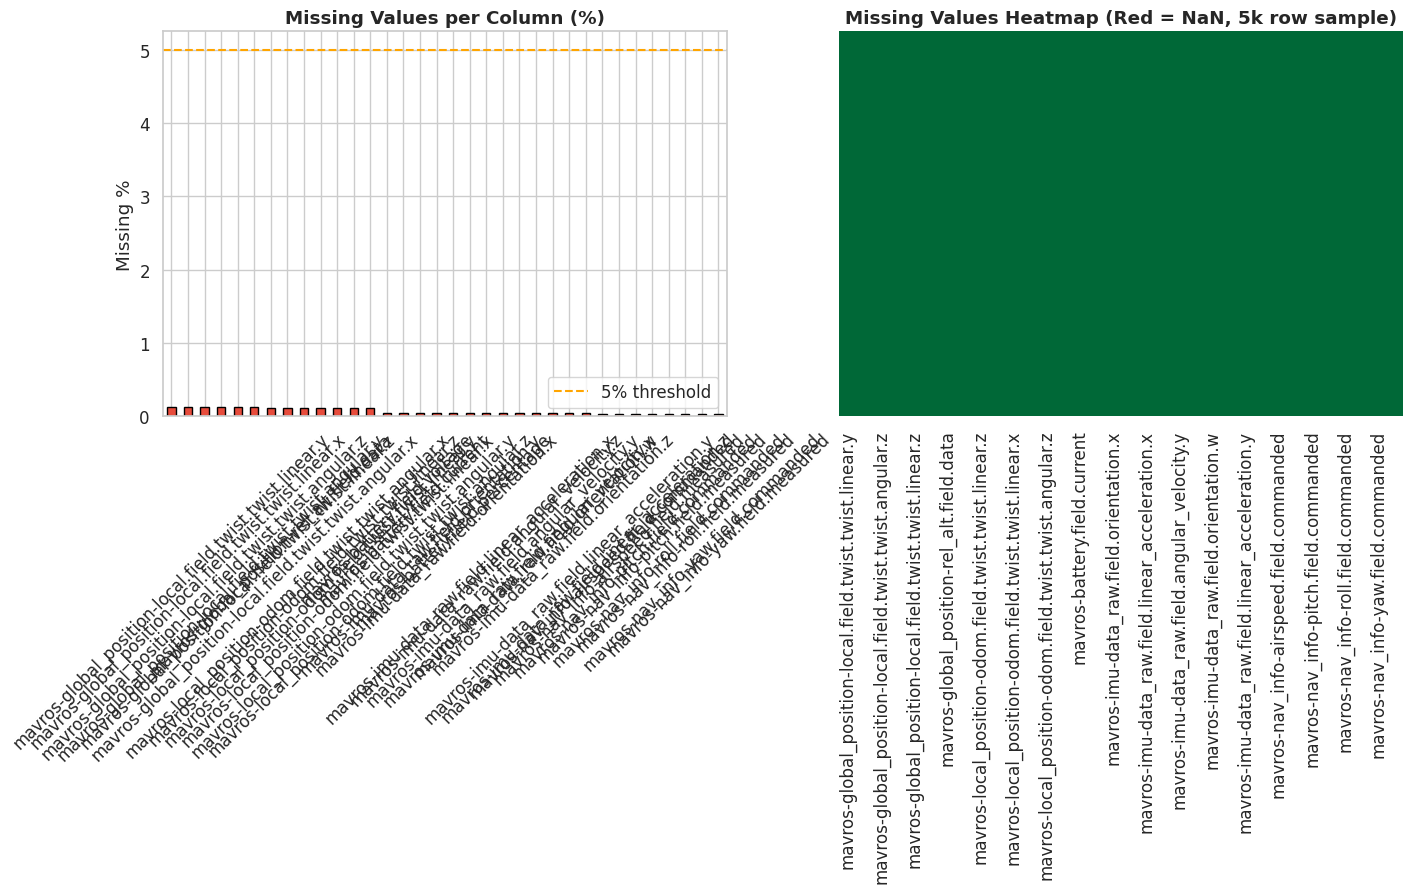

In [3]:
# 2.1 NaN Percentage per Column
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_pct.to_string())

if missing_pct.empty:
    print("✅ No missing values found in any column.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar chart of missing %
    missing_pct.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
    axes[0].set_title("Missing Values per Column (%)", fontweight='bold')
    axes[0].set_ylabel("Missing %")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(5, color='orange', linestyle='--', label='5% threshold')
    axes[0].legend()

    # Heatmap (sample 5000 rows for speed)
    sample = df[missing_pct.index].sample(min(5000, len(df)), random_state=42)
    sns.heatmap(sample.isnull(), cbar=False, cmap="RdYlGn_r", yticklabels=False, ax=axes[1])
    axes[1].set_title("Missing Values Heatmap (Red = NaN, 5k row sample)", fontweight='bold')
    plt.tight_layout()
    plt.show()

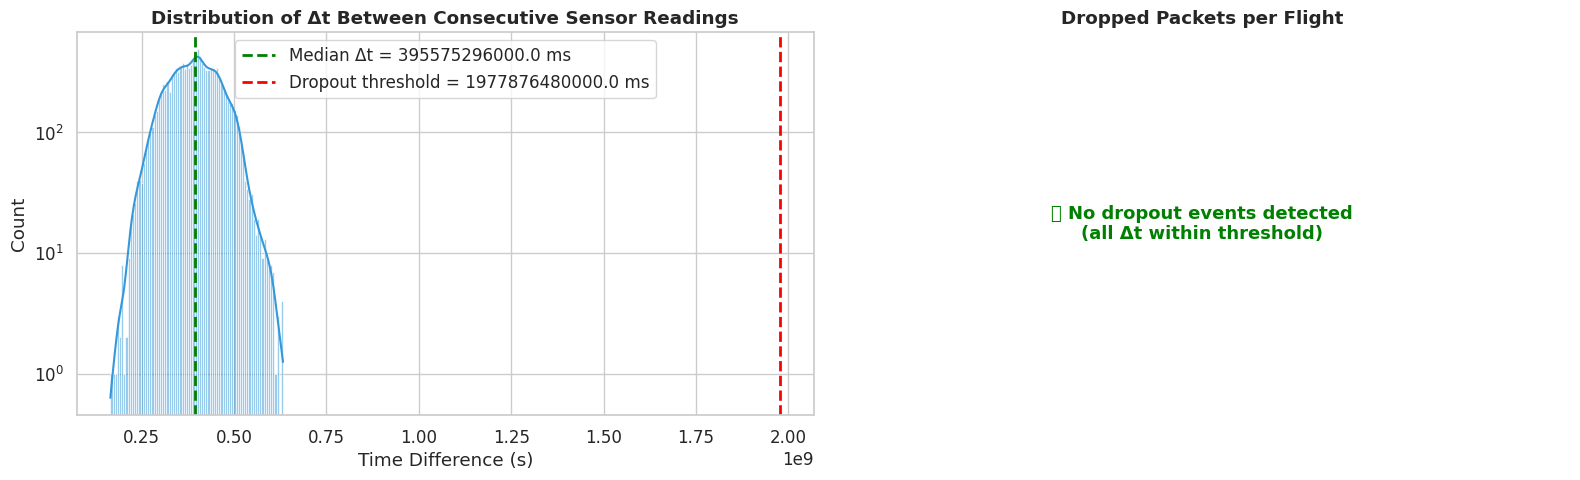

📡 Expected sample period : 395575296000.00 ms  →  0.0 Hz
⚠️  Dropout events (>1977876480000.0 ms gap): 0 (0.00% of steps)
⏱️  Max observed Δt: 632703488000.0 ms


In [4]:
# 2.2 Timestamp Gap Analysis — per-flight diff to avoid cross-flight artifacts
df['time_diff'] = df.groupby('flight_id')['%time'].diff()
td = df['time_diff'].dropna()

EXPECTED_DT = np.median(td)  # Auto-detect expected sample rate
DROPOUT_THRESHOLD = EXPECTED_DT * 5  # 5× expected → dropped packet

dropped_packets = (td > DROPOUT_THRESHOLD).sum()
dropout_pct = dropped_packets / len(td) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
sns.histplot(td[td < DROPOUT_THRESHOLD * 3], bins=80, kde=True, color='#3498db', ax=axes[0])
axes[0].axvline(EXPECTED_DT, color='green', linestyle='--', linewidth=2, label=f'Median Δt = {EXPECTED_DT*1000:.1f} ms')
axes[0].axvline(DROPOUT_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Dropout threshold = {DROPOUT_THRESHOLD*1000:.1f} ms')
axes[0].set_title("Distribution of Δt Between Consecutive Sensor Readings", fontweight='bold')
axes[0].set_xlabel("Time Difference (s)")
axes[0].set_yscale('log')
axes[0].legend()

# Per-flight dropout count
per_flight_drops = df[df['time_diff'] > DROPOUT_THRESHOLD].groupby('flight_id').size()
if per_flight_drops.empty:
    axes[1].text(0.5, 0.5, '✅ No dropout events detected\n(all Δt within threshold)',
                 ha='center', va='center', fontsize=13, transform=axes[1].transAxes,
                 color='green', fontweight='bold')
    axes[1].set_axis_off()
else:
    per_flight_drops.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black')
    axes[1].set_xlabel("Flight ID")
    axes[1].set_ylabel("Number of Dropout Events")
axes[1].set_title("Dropped Packets per Flight", fontweight='bold')

plt.tight_layout()
plt.show()

print(f"📡 Expected sample period : {EXPECTED_DT*1000:.2f} ms  →  {1/EXPECTED_DT:.1f} Hz")
print(f"⚠️  Dropout events (>{DROPOUT_THRESHOLD*1000:.1f} ms gap): {dropped_packets} ({dropout_pct:.2f}% of steps)")
print(f"⏱️  Max observed Δt: {td.max()*1000:.1f} ms")

## 3. Distributions: Classes & Flight Durations

**Hypotheses:**
- Normal flight (Class 0) rows will dominate due to ALFA dataset structure.
- Some flights may be too short to yield enough windows for the CNN — those need to be flagged.

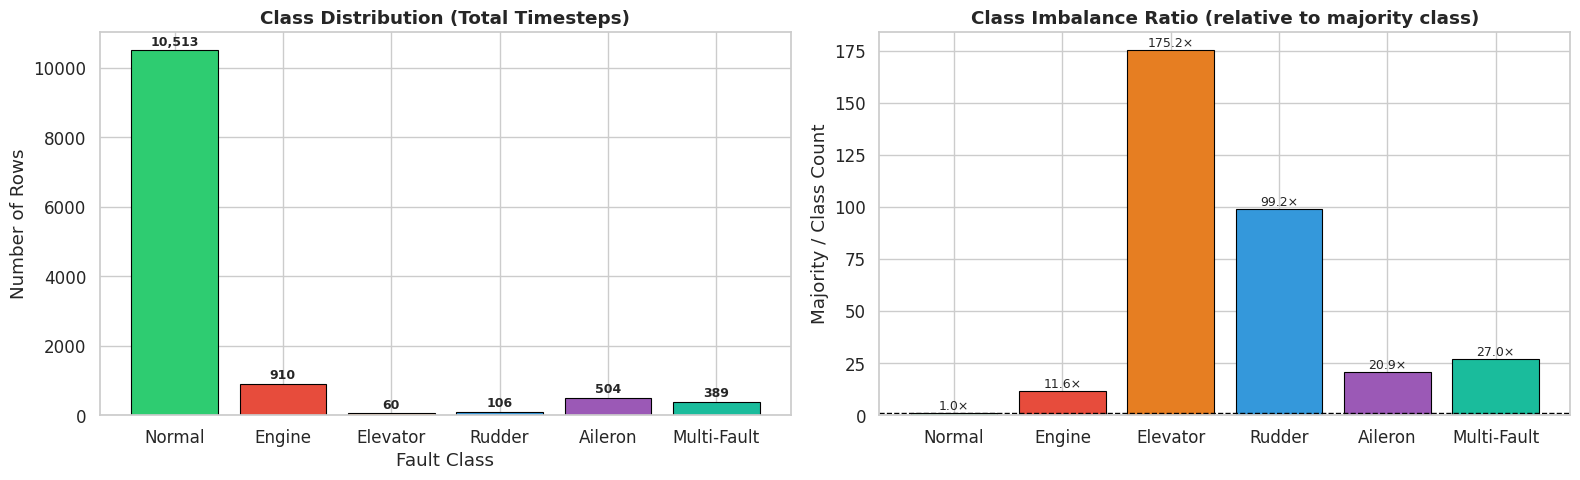


📊 Class balance summary:
  Class 0 (Normal      ):   10,513 rows  ( 84.2%)  imbalance ratio: 1.0×
  Class 1 (Engine      ):      910 rows  (  7.3%)  imbalance ratio: 11.6×
  Class 2 (Elevator    ):       60 rows  (  0.5%)  imbalance ratio: 175.2×
  Class 3 (Rudder      ):      106 rows  (  0.8%)  imbalance ratio: 99.2×
  Class 4 (Aileron     ):      504 rows  (  4.0%)  imbalance ratio: 20.9×
  Class 5 (Multi-Fault ):      389 rows  (  3.1%)  imbalance ratio: 27.0×


In [5]:
# 3.1 Class Distribution — Row counts + imbalance ratio
class_counts = df['target_label'].value_counts().sort_index()
class_names = [CLASS_MAP.get(i, str(i)) for i in class_counts.index]
majority = class_counts.max()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count bar
bars = axes[0].bar(class_names, class_counts.values, color=CLASS_COLORS, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title("Class Distribution (Total Timesteps)", fontweight='bold')
axes[0].set_ylabel("Number of Rows")
axes[0].set_xlabel("Fault Class")

# Imbalance ratio
imbalance = majority / class_counts.values
axes[1].bar(class_names, imbalance, color=CLASS_COLORS, edgecolor='black', linewidth=0.8)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1)
for i, (name, ratio) in enumerate(zip(class_names, imbalance)):
    axes[1].text(i, ratio + 0.1, f'{ratio:.1f}×', ha='center', va='bottom', fontsize=9)
axes[1].set_title("Class Imbalance Ratio (relative to majority class)", fontweight='bold')
axes[1].set_ylabel("Majority / Class Count")

plt.tight_layout()
plt.show()

print("\n📊 Class balance summary:")
for i, (idx, count) in enumerate(class_counts.items()):
    pct = count / len(df) * 100
    print(f"  Class {idx} ({CLASS_MAP.get(idx,'?'):12s}): {count:8,} rows  ({pct:5.1f}%)  imbalance ratio: {majority/count:.1f}×")

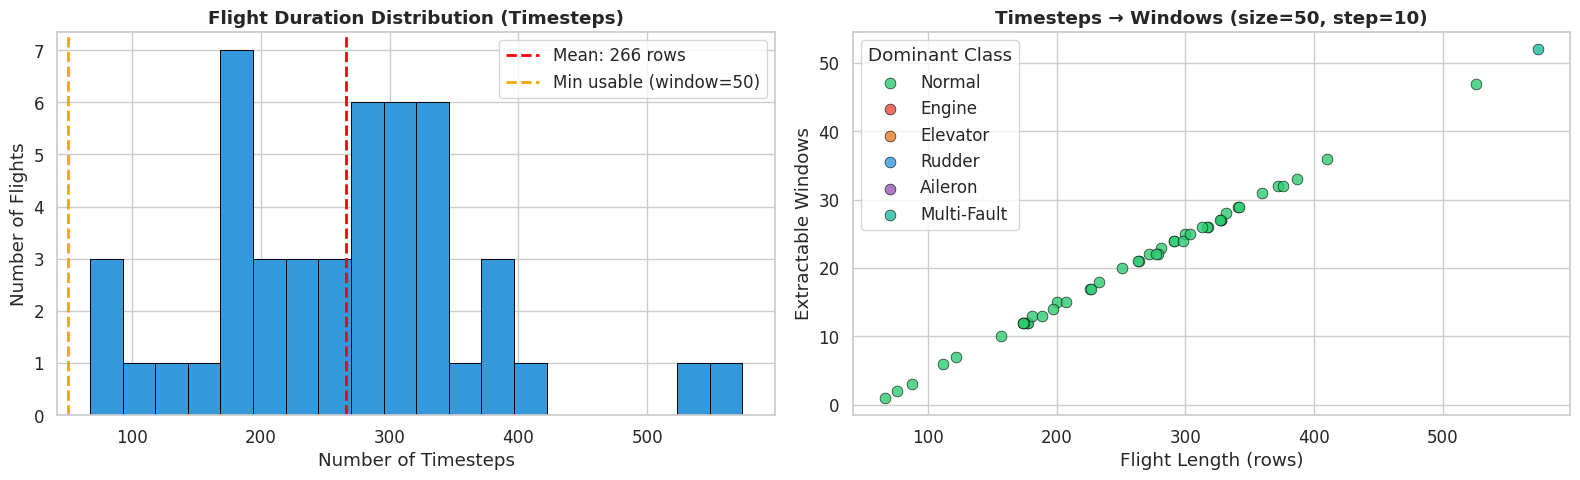

✅ Total flights: 47
⚠️  Flights too short for even 1 window: 0 (IDs: [])
📦 Total extractable windows: 992


In [6]:
# 3.2 Flight Duration Distribution — critical for window design
WINDOW_SIZE = 50     # Expected CNN window (adjust to match your config)
WINDOW_STEP = 10

flight_stats = df.groupby('flight_id').agg(
    n_rows=('target_label', 'count'),
    dominant_class=('target_label', lambda x: x.mode()[0]),
    duration_s=('%time', lambda x: x.max() - x.min())
).reset_index()
flight_stats['class_name'] = flight_stats['dominant_class'].map(CLASS_MAP)
flight_stats['n_windows'] = ((flight_stats['n_rows'] - WINDOW_SIZE) / WINDOW_STEP).clip(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of flight lengths
axes[0].hist(flight_stats['n_rows'], bins=20, color='#3498db', edgecolor='black', linewidth=0.7)
axes[0].axvline(flight_stats['n_rows'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {flight_stats["n_rows"].mean():.0f} rows')
axes[0].axvline(WINDOW_SIZE, color='orange', linestyle='--', linewidth=2,
                label=f'Min usable (window={WINDOW_SIZE})')
axes[0].set_title("Flight Duration Distribution (Timesteps)", fontweight='bold')
axes[0].set_xlabel("Number of Timesteps")
axes[0].set_ylabel("Number of Flights")
axes[0].legend()

# Scatter: rows vs windows, colored by class
for label, color in zip(sorted(df['target_label'].unique()), CLASS_COLORS):
    subset = flight_stats[flight_stats['dominant_class'] == label]
    axes[1].scatter(subset['n_rows'], subset['n_windows'], label=CLASS_MAP.get(label, str(label)),
                   color=color, alpha=0.8, edgecolors='black', linewidth=0.5, s=60)
axes[1].set_title(f"Timesteps → Windows (size={WINDOW_SIZE}, step={WINDOW_STEP})", fontweight='bold')
axes[1].set_xlabel("Flight Length (rows)")
axes[1].set_ylabel("Extractable Windows")
axes[1].legend(title='Dominant Class')

plt.tight_layout()
plt.show()

too_short = flight_stats[flight_stats['n_rows'] < WINDOW_SIZE]
print(f"✅ Total flights: {len(flight_stats)}")
print(f"⚠️  Flights too short for even 1 window: {len(too_short)} (IDs: {too_short['flight_id'].tolist()})")
print(f"📦 Total extractable windows: {flight_stats['n_windows'].sum():,}")

## 4. Statistical & Variance Analysis

**Goals:**
- Identify highly correlated features (candidates for removal to reduce model complexity).
- Quantify *how much* the variance differs between Normal and Fault states — this directly informs our feature selection.

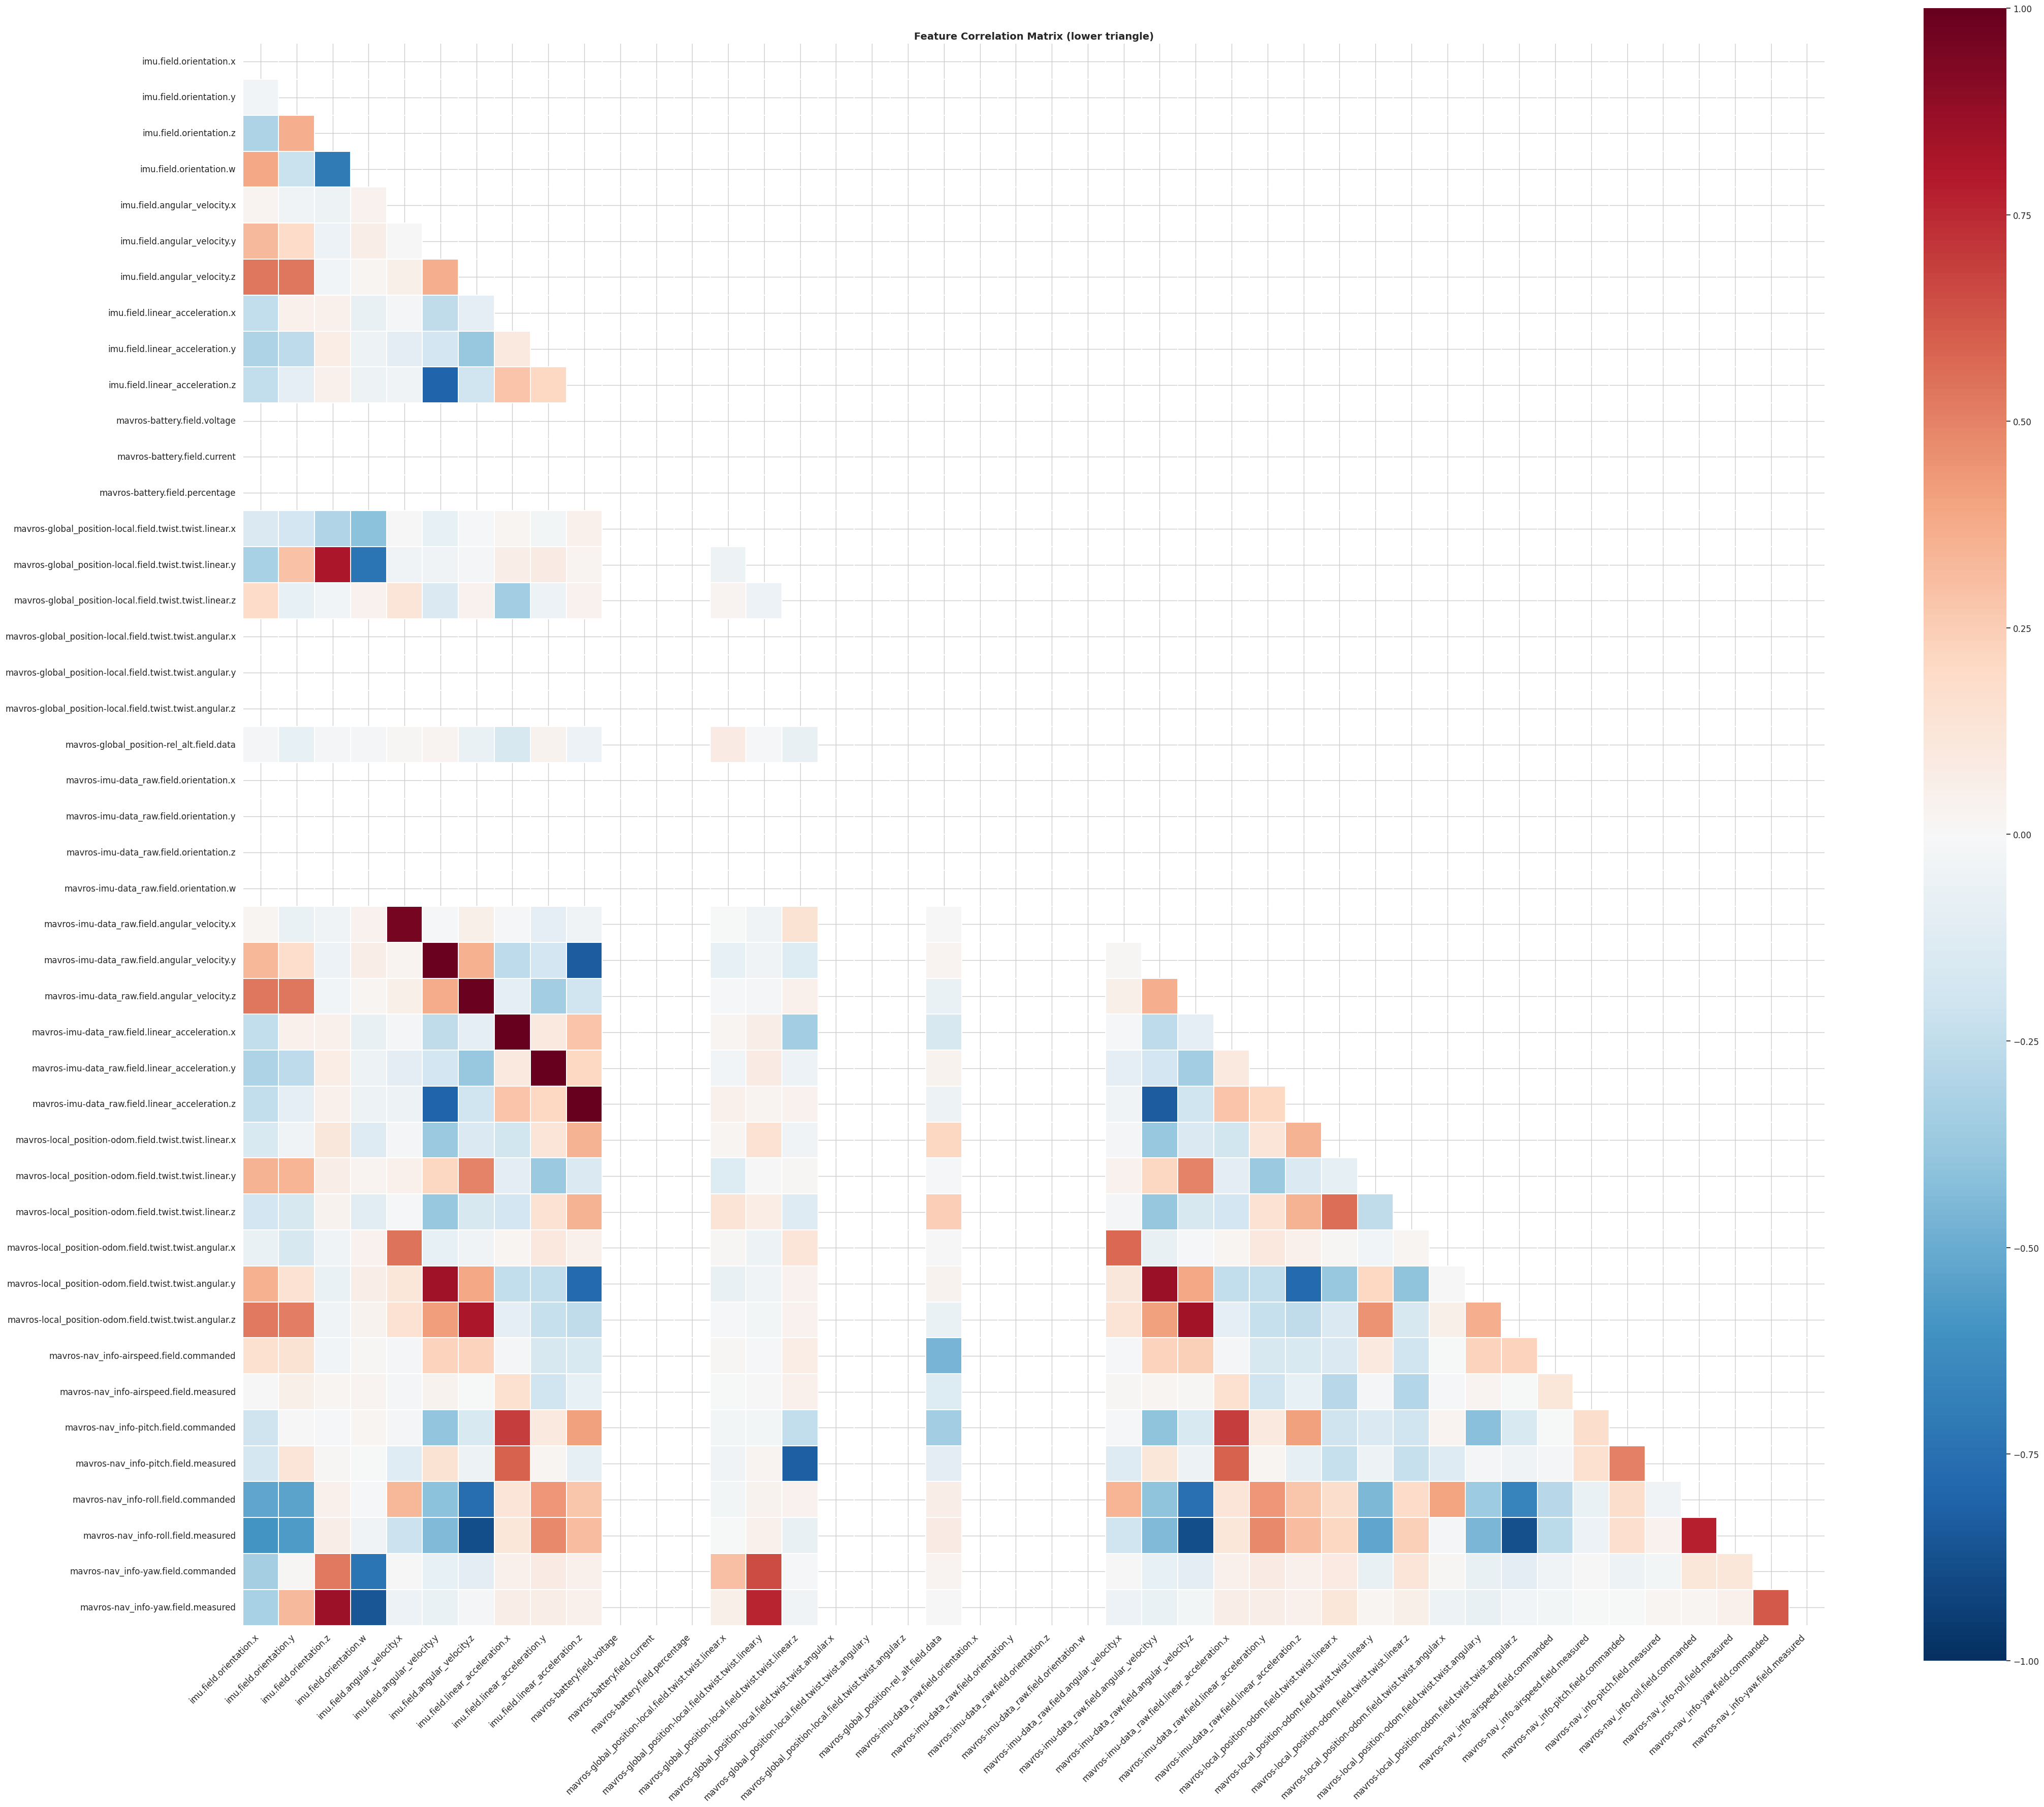

⚠️  Highly correlated feature pairs (|r| > 0.85) — consider removing one from each pair:
  imu.field.linear_acceleration.x ↔ mavros-imu-data_raw.field.linear_acceleration.x  r = +1.000
  imu.field.linear_acceleration.z ↔ mavros-imu-data_raw.field.linear_acceleration.z  r = +1.000
  imu.field.linear_acceleration.y ↔ mavros-imu-data_raw.field.linear_acceleration.y  r = +1.000
  imu.field.angular_velocity.z ↔ mavros-imu-data_raw.field.angular_velocity.z  r = +0.991
  imu.field.angular_velocity.y ↔ mavros-imu-data_raw.field.angular_velocity.y  r = +0.985
  imu.field.angular_velocity.x ↔ mavros-imu-data_raw.field.angular_velocity.x  r = +0.960
  mavros-imu-data_raw.field.angular_velocity.z ↔ mavros-nav_info-roll.field.measured  r = -0.887
  imu.field.angular_velocity.z ↔ mavros-nav_info-roll.field.measured  r = -0.885
  mavros-local_position-odom.field.twist.twist.angular.z ↔ mavros-nav_info-roll.field.measured  r = -0.882
  mavros-imu-data_raw.field.angular_velocity.y ↔ mavros-local_positi

In [7]:
# 4.1 Correlation Heatmap (numeric sensor features only)
exclude_cols = ['%time', 'flight_id', 'target_label', 'time_diff', 'class_name']
feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'float32', 'int64', 'int32']]

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(max(10, len(feature_cols)), max(8, len(feature_cols)-2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=len(feature_cols) <= 15,
            fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Matrix (lower triangle)", fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Report highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if high_corr_pairs:
    print("⚠️  Highly correlated feature pairs (|r| > 0.85) — consider removing one from each pair:")
    for a, b, v in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a:20s} ↔ {b:20s}  r = {v:+.3f}")
else:
    print("✅ No highly correlated pairs found (threshold: |r| > 0.85)")

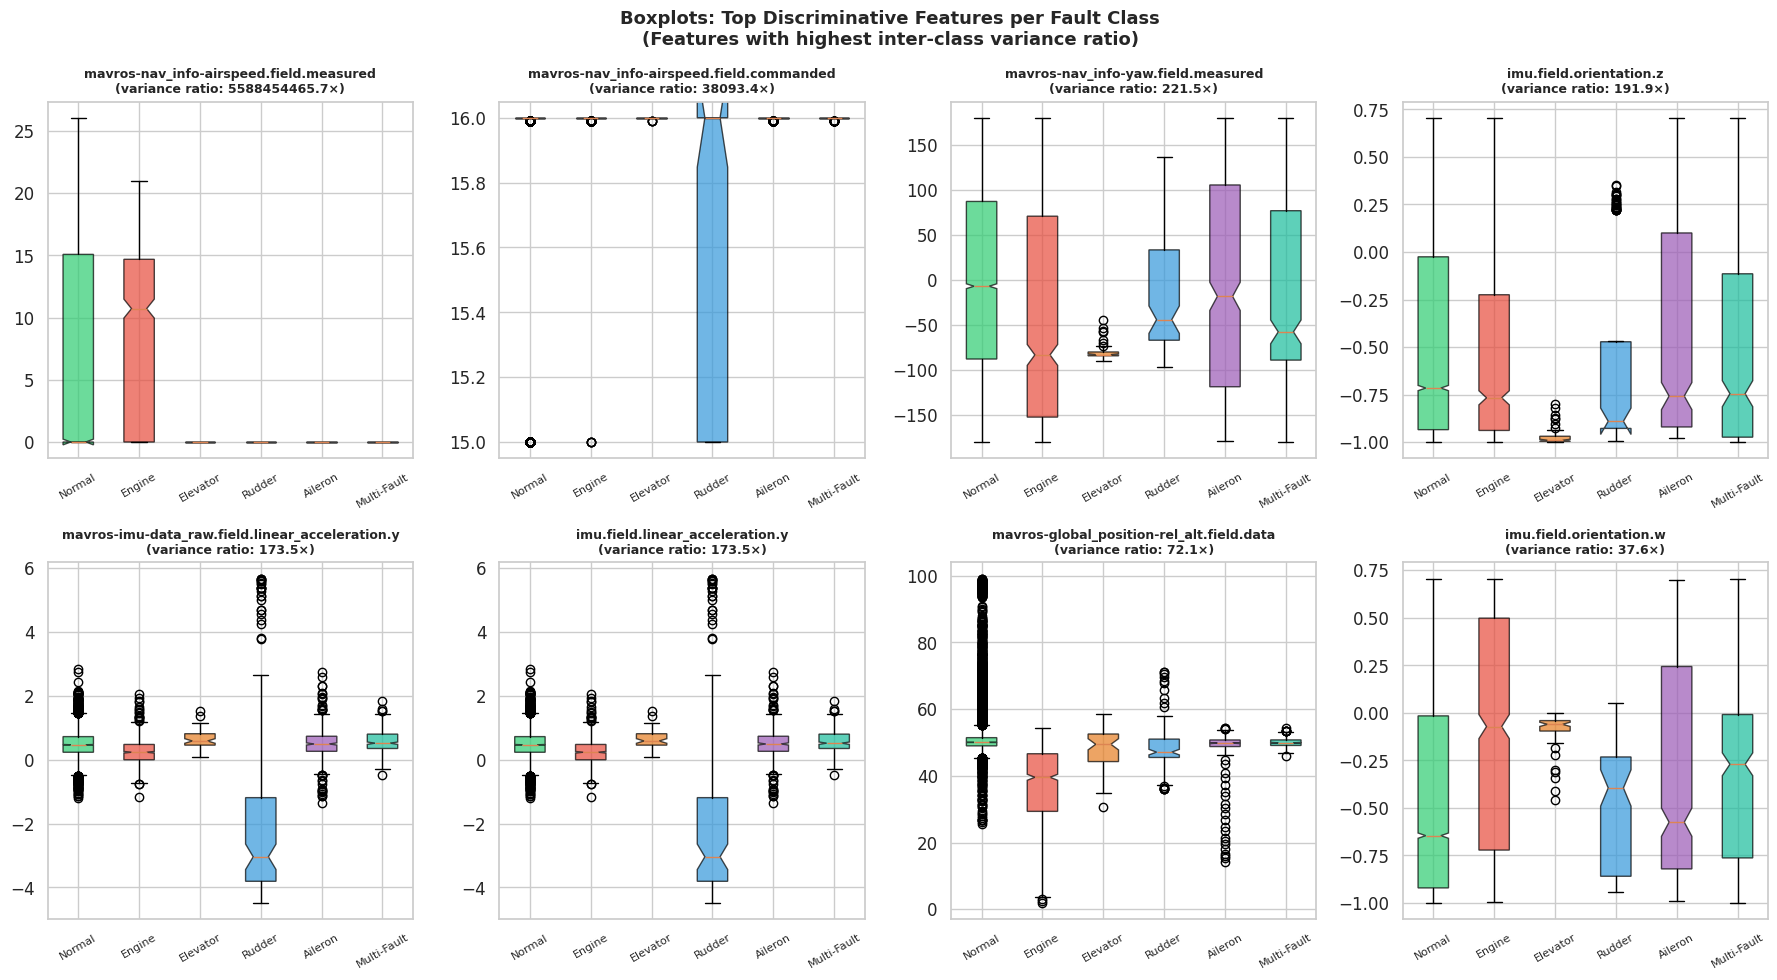


🏆 Feature discriminative power ranking (variance ratio):
  mavros-nav_info-airspeed.field.measured: 5588454465.72×
  mavros-nav_info-airspeed.field.commanded: 38093.39×
  mavros-nav_info-yaw.field.measured: 221.54×
  imu.field.orientation.z  : 191.93×
  mavros-imu-data_raw.field.linear_acceleration.y: 173.55×
  imu.field.linear_acceleration.y: 173.47×
  mavros-global_position-rel_alt.field.data:  72.12×
  imu.field.orientation.w  :  37.65×


In [8]:
# 4.2 Per-Class Feature Variance Analysis
# Shows WHICH features have the most discriminative power between classes

top_n = min(8, len(feature_cols))  # Plot top N most discriminative features

# Variance ratio: max class variance / min class variance  
class_variances = df.groupby('target_label')[feature_cols].var()
variance_ratio = class_variances.max() / (class_variances.min() + 1e-8)
top_discriminative = variance_ratio.sort_values(ascending=False).head(top_n).index.tolist()

fig, axes = plt.subplots(2, (top_n+1)//2, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_discriminative):
    data_list = [df[df['target_label'] == cls][feat].dropna().values
                 for cls in sorted(df['target_label'].unique())]
    bp = axes[i].boxplot(data_list, patch_artist=True, notch=True,
                         labels=[CLASS_MAP.get(c, str(c)) for c in sorted(df['target_label'].unique())])
    for patch, color in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f"{feat}\n(variance ratio: {variance_ratio[feat]:.1f}×)", fontweight='bold', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots: Top Discriminative Features per Fault Class\n(Features with highest inter-class variance ratio)",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n🏆 Feature discriminative power ranking (variance ratio):")
for feat, ratio in variance_ratio.sort_values(ascending=False).head(top_n).items():
    print(f"  {feat:25s}: {ratio:6.2f}×")

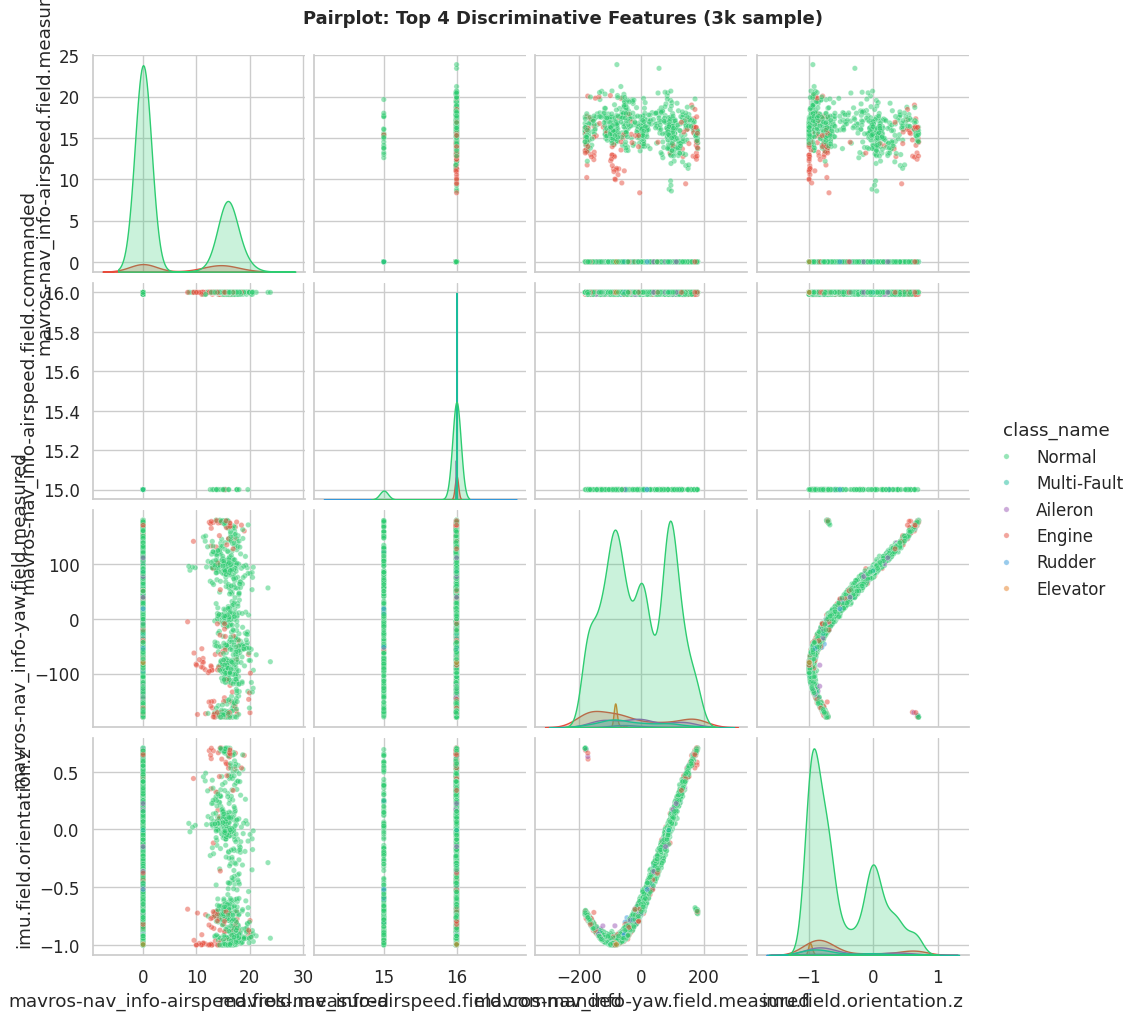

In [9]:
# 4.3 Pairplot of top 4 most discriminative features (colored by class)
top4 = top_discriminative[:4]
pair_df = df[top4 + ['class_name']].dropna().sample(min(3000, len(df)), random_state=42)

g = sns.pairplot(pair_df, hue='class_name',
                 palette={CLASS_MAP[k]: v for k, v in zip(range(6), CLASS_COLORS) if CLASS_MAP[k] in pair_df['class_name'].unique()},
                 plot_kws={'alpha': 0.5, 's': 15},
                 diag_kind='kde')
g.figure.suptitle("Pairplot: Top 4 Discriminative Features (3k sample)", y=1.02, fontweight='bold', fontsize=13)
plt.show()

## 5. Time-Series Fault Signatures

**Goal:** Visually prove that each fault class creates a distinct signature in the raw sensor data. If the signatures are visually separable, the 1D-CNN *will* be able to learn them.

We pick one representative flight per fault class and overlay the most discriminative sensor channels.

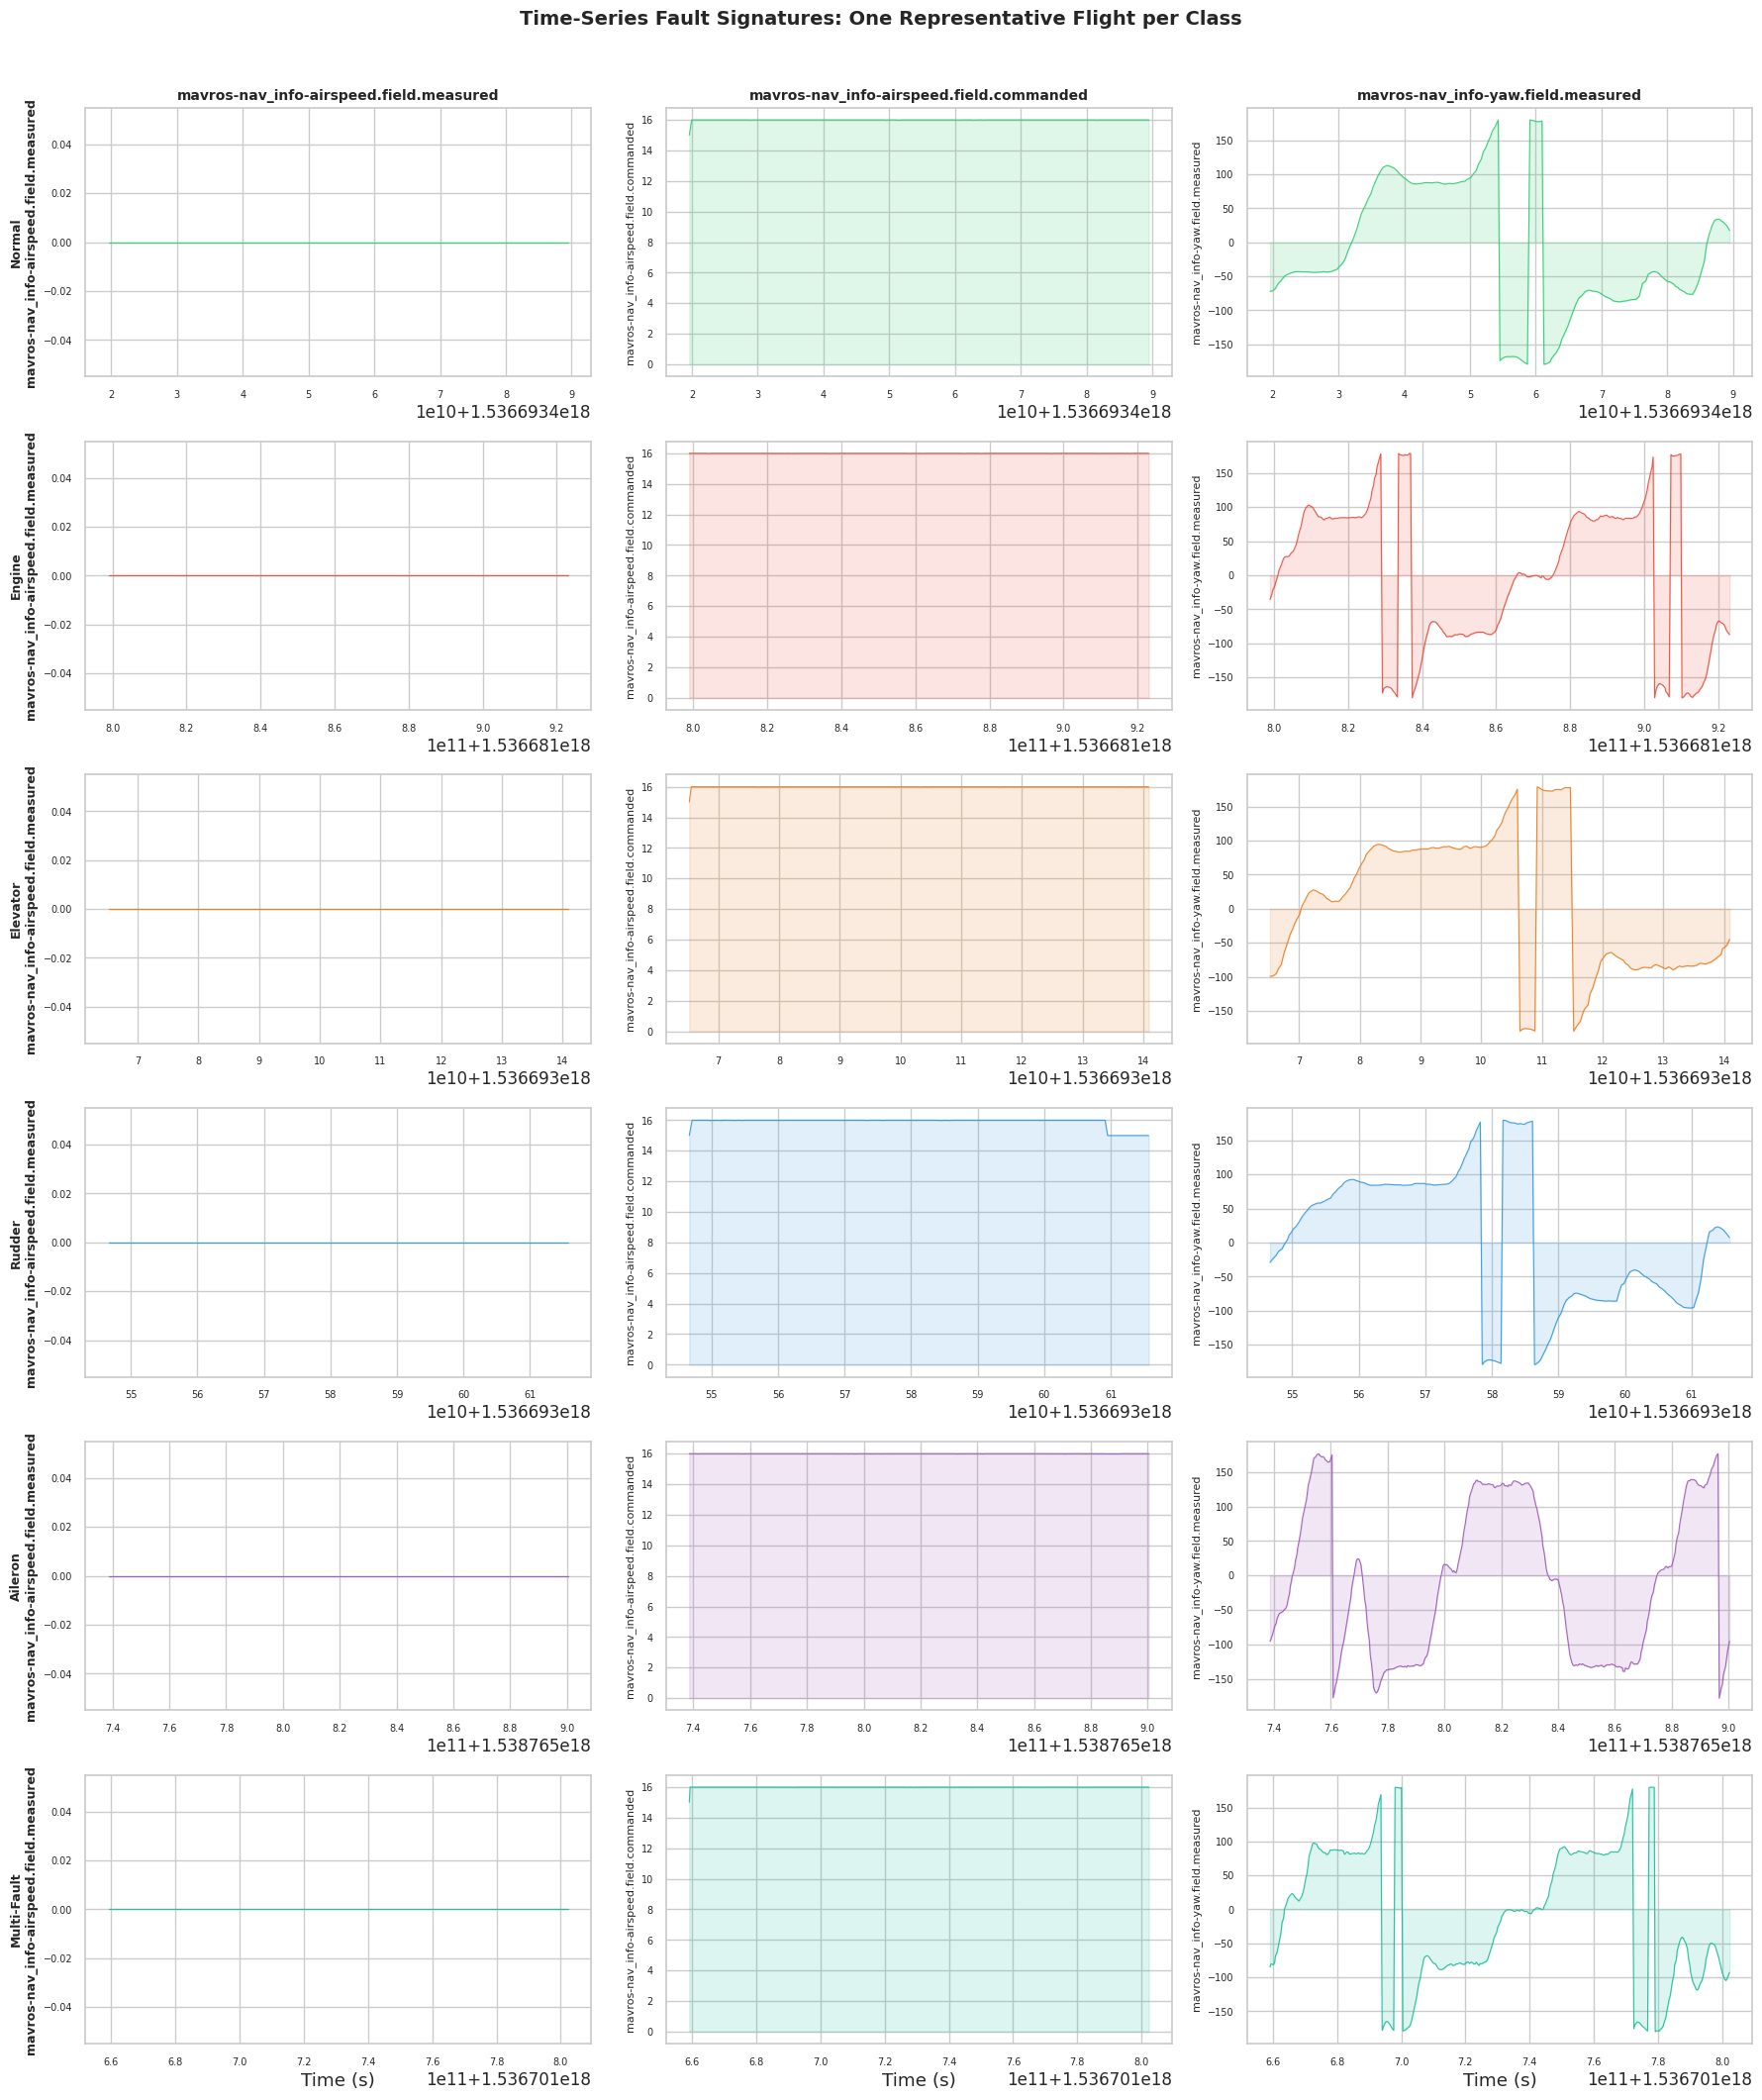

In [10]:
# 5.1 Multi-channel overlay: one flight per class
plot_features = top_discriminative[:3]  # Top 3 most discriminative
unique_classes = sorted(df['target_label'].unique())

fig, axes = plt.subplots(len(unique_classes), len(plot_features),
                          figsize=(18, 3.5 * len(unique_classes)), sharex=False)

if len(unique_classes) == 1:
    axes = axes[np.newaxis, :]

for row_idx, cls in enumerate(unique_classes):
    # Pick one representative flight for this class
    cls_flights = df[df['target_label'] == cls]['flight_id'].unique()
    rep_flight = cls_flights[len(cls_flights)//2]  # middle flight
    flight_df = df[(df['flight_id'] == rep_flight)].copy().reset_index(drop=True)

    for col_idx, feat in enumerate(plot_features):
        ax = axes[row_idx, col_idx]
        if feat in flight_df.columns:
            ax.plot(flight_df['%time'], flight_df[feat],
                    color=CLASS_COLORS[row_idx], linewidth=0.8, alpha=0.9)
            ax.fill_between(flight_df['%time'], flight_df[feat],
                            alpha=0.15, color=CLASS_COLORS[row_idx])
        ax.set_ylabel(feat, fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(f"{CLASS_MAP.get(cls, cls)}\n{feat}", fontsize=9, fontweight='bold')
        if row_idx == 0:
            ax.set_title(feat, fontsize=10, fontweight='bold')
        if row_idx == len(unique_classes) - 1:
            ax.set_xlabel("Time (s)")
        ax.tick_params(labelsize=7)

fig.suptitle("Time-Series Fault Signatures: One Representative Flight per Class",
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

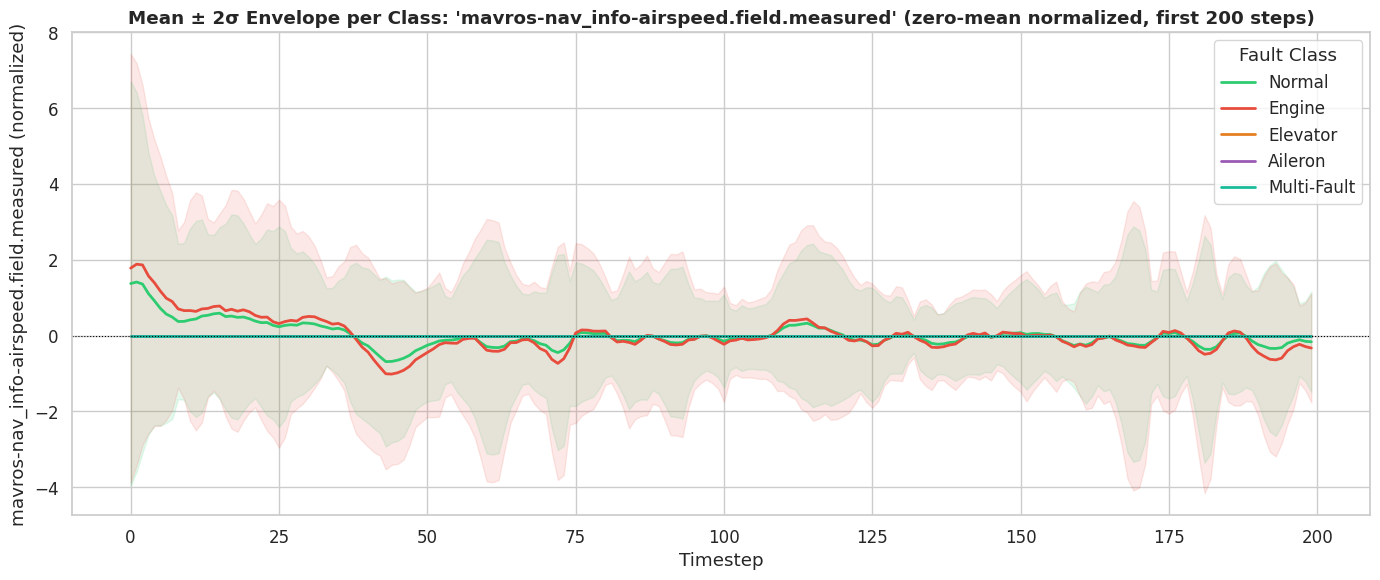

In [11]:
# 5.2 Signal Statistics per Class: Mean ± 2σ envelope
sig_feat = top_discriminative[0]  # Best discriminative feature
SEGMENT_LEN = 200  # Normalize each flight to this length for overlay

fig, ax = plt.subplots(figsize=(14, 6))

for cls, color in zip(unique_classes, CLASS_COLORS):
    cls_flights = df[df['target_label'] == cls]['flight_id'].unique()
    segments = []
    for fid in cls_flights:
        seg = df[df['flight_id'] == fid][sig_feat].dropna().values
        if len(seg) >= SEGMENT_LEN:
            seg = seg[:SEGMENT_LEN]
            # Normalize to zero mean
            seg = seg - seg.mean()
            segments.append(seg)
    if segments:
        arr = np.array(segments)
        mean = arr.mean(axis=0)
        std = arr.std(axis=0)
        t = np.arange(SEGMENT_LEN)
        ax.plot(t, mean, color=color, label=CLASS_MAP.get(cls, str(cls)), linewidth=2)
        ax.fill_between(t, mean - 2*std, mean + 2*std, color=color, alpha=0.12)

ax.set_title(f"Mean ± 2σ Envelope per Class: '{sig_feat}' (zero-mean normalized, first {SEGMENT_LEN} steps)",
             fontweight='bold')
ax.set_xlabel("Timestep")
ax.set_ylabel(f"{sig_feat} (normalized)")
ax.legend(title="Fault Class", loc='upper right')
ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Sliding Window Feasibility Analysis

This is critical for the 1D-CNN pipeline. We need to verify:
1. **Window coverage** — how much of each flight is covered by our sliding window.
2. **Label purity** — what fraction of windows contain a mix of classes (boundary windows).
3. **Class balance after windowing** — does our window extraction worsen or maintain the imbalance?

📦 Total windows extracted: 1,039
🔀 Mixed-label windows: 143 (13.8%)
✅ Pure windows: 896 (86.2%)


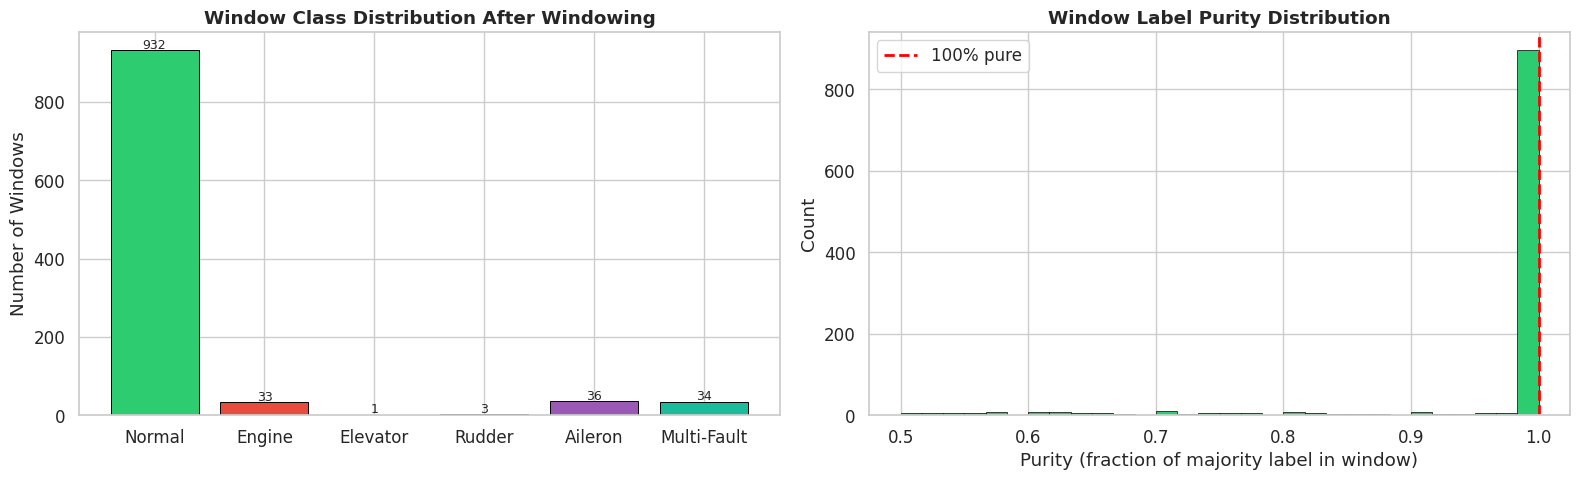

In [12]:
# 6.1 Simulate sliding window extraction & check label purity
WINDOW_SIZE = 50    # adjust to match your 1D-CNN config
WINDOW_STEP = 10

window_records = []

for fid in df['flight_id'].unique():
    flight_df = df[df['flight_id'] == fid].reset_index(drop=True)
    labels_arr = flight_df['target_label'].values
    n = len(labels_arr)
    for start in range(0, n - WINDOW_SIZE + 1, WINDOW_STEP):
        window_labels = labels_arr[start:start + WINDOW_SIZE]
        majority_label = int(np.bincount(window_labels).argmax())
        purity = (window_labels == majority_label).mean()
        window_records.append({
            'flight_id': fid,
            'window_start': start,
            'majority_label': majority_label,
            'purity': purity,
            'is_mixed': purity < 1.0
        })

win_df = pd.DataFrame(window_records)

print(f"📦 Total windows extracted: {len(win_df):,}")
print(f"🔀 Mixed-label windows: {win_df['is_mixed'].sum():,} ({win_df['is_mixed'].mean()*100:.1f}%)")
print(f"✅ Pure windows: {(~win_df['is_mixed']).sum():,} ({(~win_df['is_mixed']).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Window class distribution
win_class_counts = win_df['majority_label'].value_counts().sort_index()
axes[0].bar([CLASS_MAP.get(i, str(i)) for i in win_class_counts.index],
             win_class_counts.values,
             color=[CLASS_COLORS[i] for i in win_class_counts.index],
             edgecolor='black', linewidth=0.7)
axes[0].set_title("Window Class Distribution After Windowing", fontweight='bold')
axes[0].set_ylabel("Number of Windows")
for i, v in enumerate(win_class_counts.values):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=9)

# Purity histogram
axes[1].hist(win_df['purity'], bins=30, color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='100% pure')
axes[1].set_title("Window Label Purity Distribution", fontweight='bold')
axes[1].set_xlabel("Purity (fraction of majority label in window)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# 6.2 EDA Summary Report
print("=" * 65)
print("         EDA SUMMARY — PX4 FAULT CLASSIFIER")
print("=" * 65)
print(f"\n📁 Dataset shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🛩️  Flights            : {df['flight_id'].nunique()}")
print(f"🏷️  Fault classes      : {df['target_label'].nunique()} ({list(CLASS_MAP.values())})")
print(f"\n📡 Sensor rate        : {1/EXPECTED_DT:.1f} Hz (Δt = {EXPECTED_DT*1000:.1f} ms)")
print(f"⚠️  Dropout events     : {dropped_packets} ({dropout_pct:.2f}%)")
print(f"🔲 Missing value cols : {len(missing_pct)}")

print(f"\n⚖️  Most imbalanced class: {class_counts.idxmin()} ({CLASS_MAP.get(class_counts.idxmin(),'?')})")
print(f"   Imbalance ratio    : {majority/class_counts.min():.1f}×")
print(f"   → Consider: class_weight in loss OR oversampling with SMOTE")

print(f"\n📦 Sliding windows    : {len(win_df):,} (size={WINDOW_SIZE}, step={WINDOW_STEP})")
print(f"🔀 Mixed-label windows: {win_df['is_mixed'].sum():,} ({win_df['is_mixed'].mean()*100:.1f}%)")
if win_df['is_mixed'].mean() > 0.05:
    print(f"   → Consider: dropping mixed windows OR using last-label assignment")
else:
    print(f"   → ✅ Label purity is acceptable")

print(f"\n🔬 Top discriminative features: {', '.join(top_discriminative[:5])}")
if high_corr_pairs:
    print(f"📉 Highly correlated pairs    : {len(high_corr_pairs)} (see Section 4.1)")
print("=" * 65)

         EDA SUMMARY — PX4 FAULT CLASSIFIER

📁 Dataset shape      : 12,482 rows × 49 columns
🛩️  Flights            : 47
🏷️  Fault classes      : 6 (['Normal', 'Engine', 'Elevator', 'Rudder', 'Aileron', 'Multi-Fault'])

📡 Sensor rate        : 0.0 Hz (Δt = 395575296000.0 ms)
⚠️  Dropout events     : 0 (0.00%)
🔲 Missing value cols : 34

⚖️  Most imbalanced class: 2 (Elevator)
   Imbalance ratio    : 175.2×
   → Consider: class_weight in loss OR oversampling with SMOTE

📦 Sliding windows    : 1,039 (size=50, step=10)
🔀 Mixed-label windows: 143 (13.8%)
   → Consider: dropping mixed windows OR using last-label assignment

🔬 Top discriminative features: mavros-nav_info-airspeed.field.measured, mavros-nav_info-airspeed.field.commanded, mavros-nav_info-yaw.field.measured, imu.field.orientation.z, mavros-imu-data_raw.field.linear_acceleration.y
📉 Highly correlated pairs    : 12 (see Section 4.1)
